# 003 QAOA example

In this example, using a predefined QAOA ansatz module, we will find a Max-Cut solution of the given graph with TorchPenny.
[Max-Cut](https://en.wikipedia.org/wiki/Maximum_cut) is a typical example of NP-Complete problem.
In quantum optimization, we can solve it with Ising-encoding Hamiltonian and QAOA method.

In [1]:
import sys
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "torchpenny" / "module.py").is_file()
)
sys.path.insert(0, str(project_root))

Let's define an example graph to find solve max-cut problem.

In [2]:
import networkx as nx

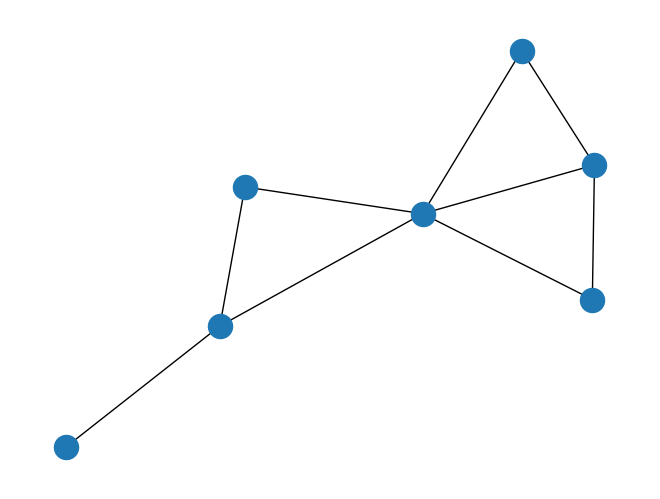

In [3]:
edge_list = [[0, 1], [1, 2], [2, 0], [3, 2], [4,6], [4,3], [4,2], [0,5], [2, 6]]
G = nx.Graph(edge_list)
nx.draw(G, with_labels=False)

With the graph connection, we can construct a corresponding Ising-like Hamiltonian that measure the number of cut of the state.

$$H =  \frac{1}{2} \sum_{i>j}^{N} (I - Z_i Z_j)$$
$$max(\langle \psi | H | \psi \rangle)$$


In [16]:
import pennylane as qml
import torch

In [17]:
pauliZ_words = sum([0.5*qml.PauliZ(i)@qml.PauliZ(j) for i, j in edge_list])
Is = -0.5*len(edge_list)*qml.I(wires=[i for i in range(len(G.nodes))])
H = Is + pauliZ_words
print(H.pauli_rep)

-4.5 * I
+ 0.5 * Z(0) @ Z(1)
+ 0.5 * Z(1) @ Z(2)
+ 0.5 * Z(2) @ Z(0)
+ 0.5 * Z(3) @ Z(2)
+ 0.5 * Z(4) @ Z(6)
+ 0.5 * Z(4) @ Z(3)
+ 0.5 * Z(4) @ Z(2)
+ 0.5 * Z(0) @ Z(5)
+ 0.5 * Z(2) @ Z(6)


## Ansatz and QAOA module

`QAOAAnsatz` is an ansatz based on Trotter method. 

$$H = H_{mixer} + H_{ZZ}$$
$$QAOAAnsatz(N, H, P) = \Pi_{i=1}^P U_{ZZ}(N)U_{mixer}(N)$$

- $N$: Number of qubit.
- $H$: QAOA Hamiltonian.
- $P$: QAOA step.

In [26]:
from torchpenny.lib import QAOA, QAOAAnsatz

In [27]:
wires = len(G.nodes)
#t_layer = TrotterAnsatz(wires= wires , ops=H.pauli_rep, reps=2)
qaoa_layer = QAOAAnsatz(wires= wires , ops=H.pauli_rep, p=1)
qaoa = QAOA(
    ops=H.pauli_rep, 
    ansatz=qaoa_layer, 
    wires=wires, 
    qnode_kwargs={"diff_method":"backprop"}
    )

(<Figure size 2900x800 with 1 Axes>, <Axes: >)

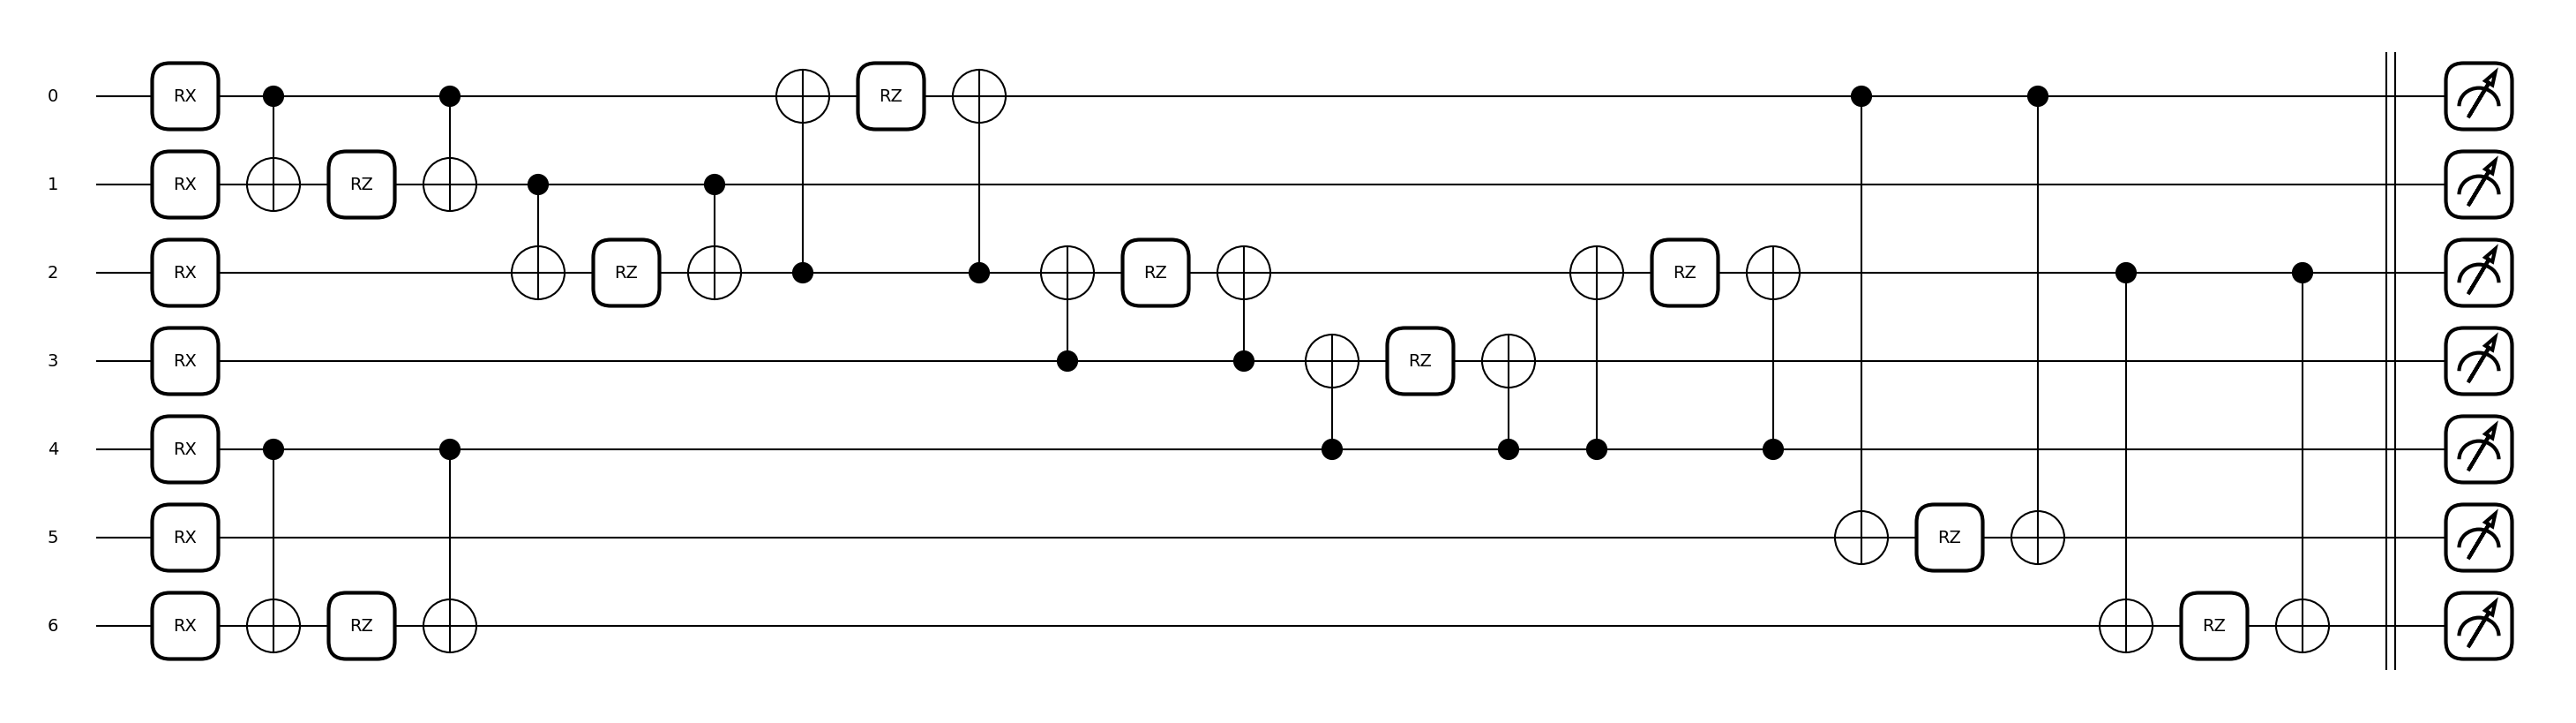

In [28]:
qml.draw_mpl(qaoa.qnode)()  

You can directly generate the ansatz from the nextwork graph.

In [29]:
qaoa = QAOA.from_nx_graph(G,  qaoa_layer,  wires, qnode_kwargs={"diff_method":"backprop"} )

In [30]:
qaoa() # Measurement

tensor([-0.7503], dtype=torch.float64, grad_fn=<ViewBackward0>)

In [31]:
from tqdm import tqdm
from torch.optim import Adam

optim = Adam(qaoa.parameters(), lr = 0.01)

In [32]:
epoches = 350
loss_history = []
with tqdm(epoches) as pbar:
    for e in range(epoches):
        pbar.set_description(f'Epoch - {e}')
        optim.zero_grad()
        loss = qaoa()
        loss.backward()
        optim.step()
        loss_history.append(loss.item())
        pbar.set_postfix(loss = loss.item())

Epoch - 349: : 0it [00:03, ?it/s, loss=-6.99]


In [33]:
cut_value = (-torch.tensor(loss_history)).max()
print("Cut Value:", cut_value)

Cut Value: tensor(6.9910)


In [34]:
from matplotlib import pyplot as plt

Text(0, 0.5, 'Cut')

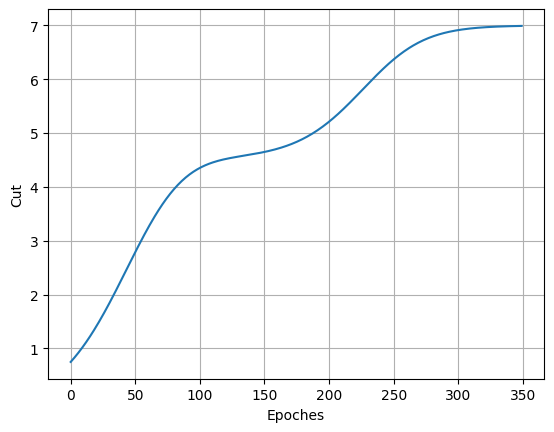

In [35]:
fig, ax = plt.subplots(1,1)
ax.plot(-torch.tensor(loss_history))
ax.grid()
ax.set_xlabel("Epoches")
ax.set_ylabel("Cut")

In [36]:
qaoa.measurement_value # Current mode measure the loss.

'loss'

In [37]:
qaoa.sample() # Change the mode of the model to meaure the sample.

tensor([[1, 0, 0,  ..., 0, 0, 1],
        [1, 1, 0,  ..., 0, 0, 1],
        [1, 1, 0,  ..., 0, 0, 1],
        ...,
        [1, 1, 0,  ..., 0, 0, 1],
        [1, 0, 0,  ..., 0, 0, 1],
        [1, 0, 0,  ..., 0, 0, 1]])

In [38]:
qaoa.set_measure(loss=False) # Automatically, Z(i) measurements are set for all qubit.

In [39]:
qaoa.measurement_value

'sample'

In [40]:
qaoa.update_qdevice("default.qubit", q_device_kwargs={"wires": wires, "shots": 10}) # Update qdevice

In [41]:
qaoa()

tensor([[1, 1, 0, 1, 0, 0, 1],
        [1, 0, 0, 1, 0, 0, 1],
        [1, 0, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1],
        [1, 1, 0, 1, 0, 0, 1]])

In [42]:
sample = qaoa()[0]

In [43]:
sample

tensor([1, 1, 0, 1, 0, 0, 1])

In [44]:
pos = nx.spring_layout(G)
target_node = (sample==0).nonzero(as_tuple=True)[0]
node_colors = ['red' if node in target_node else 'lightblue' for node in G.nodes()]

Text(0.5, 1.0, 'QAOA result: cut=7')

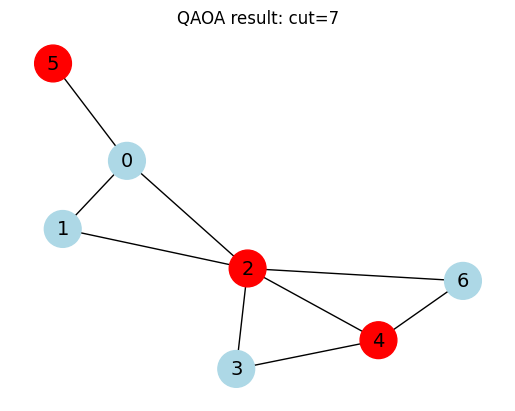

In [45]:
fig, ax = plt.subplots(1, 1)
nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=700, font_size=14, ax=ax)
ax.set_title(f"QAOA result: cut={int(cut_value+0.5)}")

In [46]:
import networkx as nx
import random
def max_cut(G, trials=1000):
    best_cut = None
    best_score = -1

    for _ in range(trials):
        # Randomly partition nodes into two sets
        cut = set()
        for node in G.nodes:
            if random.random() < 0.5:
                cut.add(node)

        # Count number of edges crossing the cut
        score = sum(1 for u, v in G.edges if (u in cut) != (v in cut))

        if score > best_score:
            best_score = score
            best_cut = cut.copy()

    # Partition: cut and complement
    other_side = set(G.nodes) - best_cut
    return best_cut, other_side, best_score

In [47]:
A, B, cut_size = max_cut(G)
print(cut_size)

7


In [48]:
target_node_2 = A
node_colors_2 = ['red' if node in target_node_2 else 'lightblue' for node in G.nodes()]

Text(0.5, 1.0, 'Classic Algorithm, cut=7')

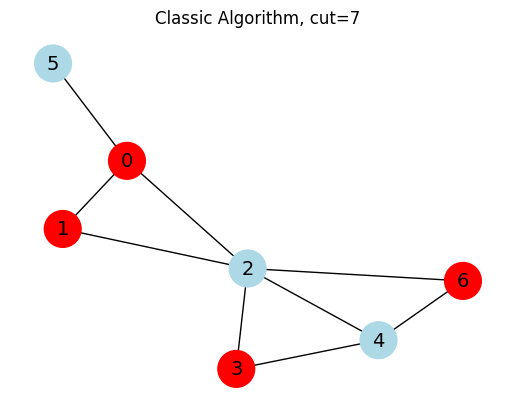

In [49]:
fig, ax = plt.subplots(1,1)
nx.draw(G, pos, with_labels=True, node_color=node_colors_2, node_size=700, font_size=14, ax=ax)
ax.set_title(f"Classic Algorithm, cut={cut_size}")